In [1]:
%pip install -q imbalanced-learn seaborn joblib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc, log_loss
)
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## # 1. Load Dataset

In [3]:
# 1. Load Dataset
df = pd.read_csv("hypertension_dataset.csv")
df.columns = df.columns.str.strip()

print("Jumlah baris dan kolom:", df.shape)
display(df.head())
print("\nInfo dataset:")
print(df.info())

print("\nMissing values per kolom:")
print(df.isna().sum())

Jumlah baris dan kolom: (1985, 11)


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No



Info dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1985 non-null   int64  
 1   Salt_Intake       1985 non-null   float64
 2   Stress_Score      1985 non-null   int64  
 3   BP_History        1985 non-null   str    
 4   Sleep_Duration    1985 non-null   float64
 5   BMI               1985 non-null   float64
 6   Medication        1186 non-null   str    
 7   Family_History    1985 non-null   str    
 8   Exercise_Level    1985 non-null   str    
 9   Smoking_Status    1985 non-null   str    
 10  Has_Hypertension  1985 non-null   str    
dtypes: float64(3), int64(2), str(6)
memory usage: 170.7 KB
None

Missing values per kolom:
Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History    

## Persiapan Data

In [8]:
# Memisahkan kolom target dan fitur
target_col = "Has_Hypertension"

# Kolom kategorikal dan numerik
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if target_col in categorical_cols:
    categorical_cols.remove(target_col)

numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

# Tangani missing value pada kolom kategorikal
# (pada dataset ini, Medication memiliki missing value)
for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

print("Kolom kategorikal:", categorical_cols)
print("Kolom numerik:", numeric_cols)

Kolom kategorikal: ['BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
Kolom numerik: ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']


## # 2. Label Encoding

In [9]:
# 2. Label Encoding
# Encode semua kolom kategorikal termasuk target
label_encoders = {}
df_encoded = df.copy()

for col in categorical_cols + [target_col]:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {list(le.classes_)}")

print("\nContoh data setelah encoding:")
display(df_encoded.head())

BP_History: ['Hypertension', 'Normal', 'Prehypertension']
Medication: ['ACE Inhibitor', 'Beta Blocker', 'Diuretic', 'Other', 'Unknown']
Family_History: ['No', 'Yes']
Exercise_Level: ['High', 'Low', 'Moderate']
Smoking_Status: ['Non-Smoker', 'Smoker']
Has_Hypertension: ['No', 'Yes']

Contoh data setelah encoding:


,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,1,6.4,25.8,4,1,1,0,1
1,32,11.7,10,1,5.4,23.4,4,0,1,0,0
2,78,9.5,3,1,7.1,18.7,4,0,2,0,0
3,38,10.0,10,0,4.2,22.1,0,0,1,0,1
4,41,9.8,1,2,5.8,16.2,3,0,2,0,0


## # 3. Distribusi Kelas

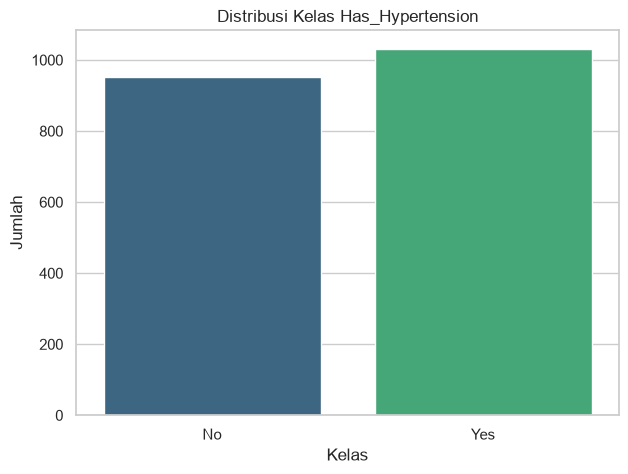

Distribusi kelas:
No: 953
Yes: 1032


In [10]:
# 3. Distribusi Kelas
target_names = label_encoders[target_col].classes_
class_counts = df_encoded[target_col].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.countplot(x=df_encoded[target_col], palette="viridis")
plt.title("Distribusi Kelas Has_Hypertension")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.xticks(ticks=np.arange(len(target_names)), labels=target_names)
plt.show()

print("Distribusi kelas:")
for i, name in enumerate(target_names):
    print(f"{name}: {class_counts.get(i, 0)}")

## # 4. Split Dataset (SMOTE belum diterapkan!)

In [11]:
# 4. Split Dataset (SMOTE belum diterapkan!)
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test :", X_test.shape)
print("Distribusi y_train sebelum SMOTE:")
print(y_train.value_counts().sort_index())

Ukuran X_train: (1588, 10)
Ukuran X_test : (397, 10)
Distribusi y_train sebelum SMOTE:
Has_Hypertension
0    762
1    826
Name: count, dtype: int64


## # 5. Terapkan SMOTE (tanpa scaling dulu)

In [12]:
# 5. Terapkan SMOTE (tanpa scaling dulu)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Ukuran X_train setelah SMOTE:", X_train_resampled.shape)
print("Distribusi y_train setelah SMOTE:")
print(pd.Series(y_train_resampled).value_counts().sort_index())

Ukuran X_train setelah SMOTE: (1652, 10)
Distribusi y_train setelah SMOTE:
Has_Hypertension
0    826
1    826
Name: count, dtype: int64


## # 6. Visualisasi Sebelum dan Sesudah SMOTE

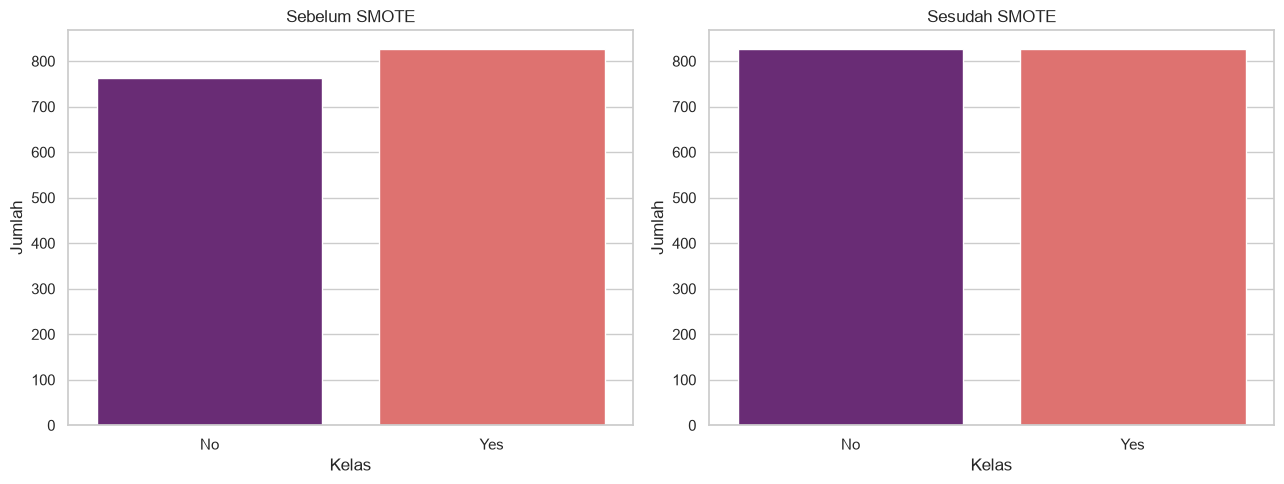

In [13]:
# 6. Visualisasi Sebelum dan Sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x=y_train, ax=axes[0], palette="magma")
axes[0].set_title("Sebelum SMOTE")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah")
axes[0].set_xticks(np.arange(len(target_names)))
axes[0].set_xticklabels(target_names)

sns.countplot(x=y_train_resampled, ax=axes[1], palette="magma")
axes[1].set_title("Sesudah SMOTE")
axes[1].set_xlabel("Kelas")
axes[1].set_ylabel("Jumlah")
axes[1].set_xticks(np.arange(len(target_names)))
axes[1].set_xticklabels(target_names)

plt.tight_layout()
plt.show()

## # 7. Scaling setelah SMOTE

In [14]:
# 7. Scaling setelah SMOTE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

Shape X_train_scaled: (1652, 10)
Shape X_test_scaled : (397, 10)


## # 8. Train Model

In [15]:
# 8. Train Model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight=None
)
rf.fit(X_train_scaled, y_train_resampled)

print("Model Random Forest berhasil dilatih.")

Model Random Forest berhasil dilatih.


## # 9. Prediksi

In [16]:
# 9. Prediksi
y_pred = rf.predict(X_test_scaled)
y_proba = rf.predict_proba(X_test_scaled)

print("Contoh hasil prediksi:")
preview = pd.DataFrame({
    "Aktual": label_encoders[target_col].inverse_transform(y_test[:10]),
    "Prediksi": label_encoders[target_col].inverse_transform(y_pred[:10])
})
display(preview)

Contoh hasil prediksi:


,Aktual,Prediksi
0,Yes,Yes
1,Yes,Yes
2,No,No
3,Yes,Yes
4,No,No
5,No,No
6,No,No
7,No,No
8,No,Yes
9,Yes,Yes


In [17]:
# Fungsi prediksi untuk data baru
def predict_hypertension(sample_dict):
    sample_df = pd.DataFrame([sample_dict])

    # Pastikan urutan kolom sama seperti data latih
    sample_df = sample_df[feature_columns].copy()

    # Encoding kolom kategorikal
    for col in categorical_cols:
        le = label_encoders[col]
        sample_df[col] = sample_df[col].fillna("Unknown").astype(str)
        sample_df[col] = le.transform(sample_df[col])

    sample_scaled = scaler.transform(sample_df)
    pred_label = rf.predict(sample_scaled)[0]
    pred_name = label_encoders[target_col].inverse_transform([pred_label])[0]
    pred_prob = rf.predict_proba(sample_scaled)[0]
    prob_df = pd.DataFrame({
        "Kelas": label_encoders[target_col].classes_,
        "Probabilitas": pred_prob
    })
    return pred_name, prob_df

# Contoh prediksi data baru
contoh_pasien = {
    "Age": 45,
    "Salt_Intake": 10.2,
    "Stress_Score": 7,
    "BP_History": "Prehypertension",
    "Sleep_Duration": 6.0,
    "BMI": 28.5,
    "Medication": "ACE Inhibitor",
    "Family_History": "Yes",
    "Exercise_Level": "Low",
    "Smoking_Status": "Smoker"
}

hasil_prediksi, probabilitas = predict_hypertension(contoh_pasien)
print("Hasil prediksi:", hasil_prediksi)
display(probabilitas)

Hasil prediksi: Yes


,Kelas,Probabilitas
0,No,0.27
1,Yes,0.73


## # 10. Evaluasi Akurasi

In [18]:
# 10. Evaluasi Akurasi dan Loss
acc = accuracy_score(y_test, y_pred)
loss = log_loss(y_test, y_proba)

print("Akurasi:", acc)
print("Loss (Log Loss):", loss)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoders[target_col].classes_
))


Akurasi: 0.9596977329974811
Loss (Log Loss): 0.1718922703879983

Classification Report:
              precision    recall  f1-score   support

          No       0.96      0.95      0.96       191
         Yes       0.96      0.97      0.96       206

    accuracy                           0.96       397
   macro avg       0.96      0.96      0.96       397
weighted avg       0.96      0.96      0.96       397



## # 11. Confusion Matrix

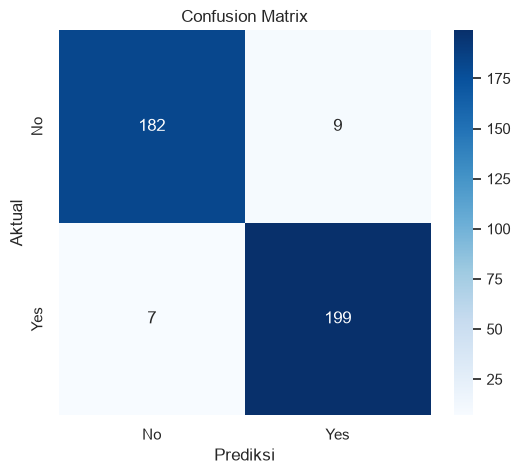

In [19]:
# 11. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_encoders[target_col].classes_,
    yticklabels=label_encoders[target_col].classes_
)
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

## # 12. ROC Curve Multi-class

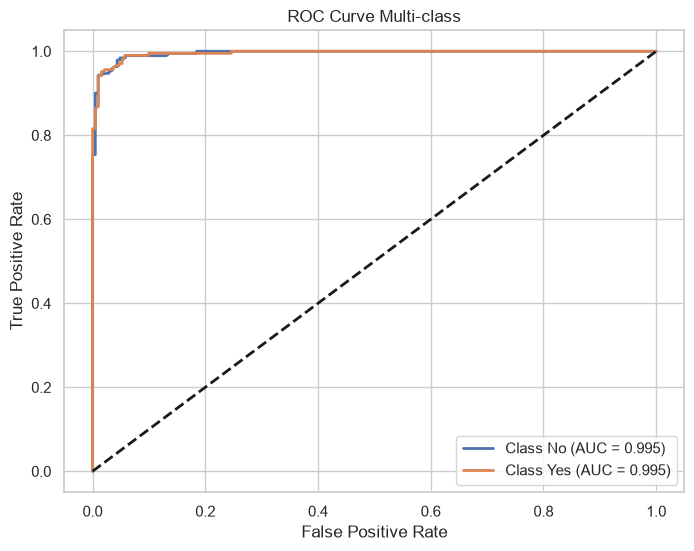

In [20]:
# 12. ROC Curve Multi-class
# Walaupun target pada dataset ini biner, kode berikut dibuat generik
# agar tetap bisa dipakai jika jumlah kelas berubah di masa depan.

n_classes = len(label_encoders[target_col].classes_)

if n_classes == 2:
    y_test_bin = label_binarize(y_test, classes=[0, 1])
    # label_binarize untuk biner menghasilkan 1 kolom, jadi dilengkapi menjadi 2 kolom
    y_test_bin = np.hstack((1 - y_test_bin, y_test_bin))
else:
    y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {label_encoders[target_col].classes_[i]} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Multi-class")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## # 13. Feature Importance

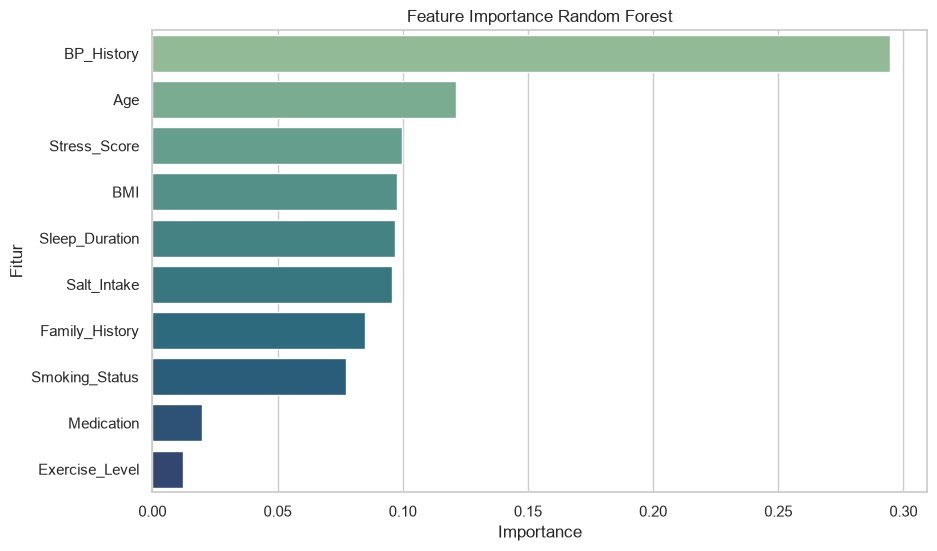

,Fitur,Importance
3,BP_History,0.294818
0,Age,0.121443
2,Stress_Score,0.099608
5,BMI,0.097583
4,Sleep_Duration,0.096743
1,Salt_Intake,0.095617
7,Family_History,0.084735
9,Smoking_Status,0.077525
6,Medication,0.019887
8,Exercise_Level,0.012041


In [22]:
# 13. Feature Importance
importances = rf.feature_importances_
feat_imp = pd.DataFrame({
    "Fitur": feature_columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="Importance", y="Fitur", palette="crest")
plt.title("Feature Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Fitur")
plt.show()

display(feat_imp)

## # 14. Visualisasi Prediksi vs Aktual

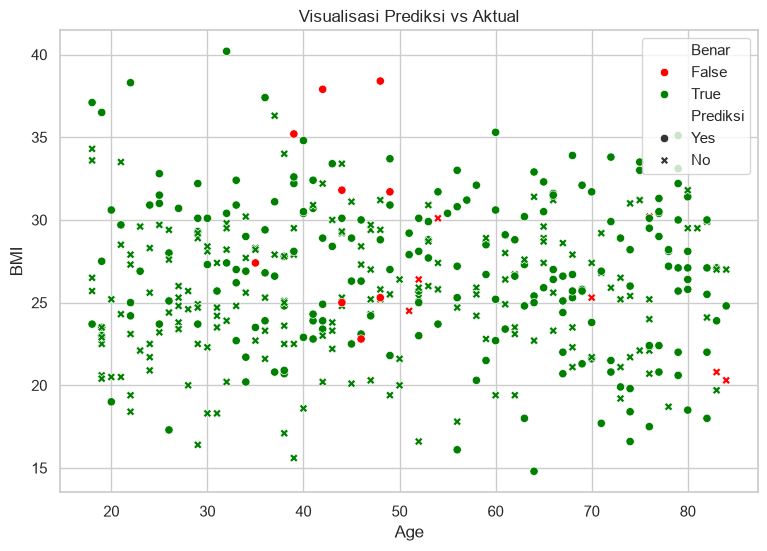

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Aktual,Prediksi,Benar
291,74,10.1,4,2,5.5,19.8,2,1,2,0,Yes,Yes,True
592,68,8.9,10,0,2.9,25.3,4,1,0,1,Yes,Yes,True
152,73,6.8,2,1,5.9,21.1,4,0,1,0,No,No,True
1668,56,7.0,6,1,7.0,25.3,1,1,2,1,Yes,Yes,True
480,30,6.9,5,1,2.5,28.1,4,1,1,0,No,No,True
1046,43,12.5,7,1,7.3,23.8,1,1,2,0,No,No,True
826,46,11.0,7,1,6.8,27.3,2,1,1,0,No,No,True
1343,32,9.5,6,2,5.4,28.2,0,1,2,0,No,No,True
838,44,6.3,6,2,4.0,31.8,4,0,2,0,No,Yes,False
1204,22,12.1,8,1,7.6,38.3,4,1,0,0,Yes,Yes,True


In [23]:
# 14. Visualisasi Prediksi vs Aktual
results_df = X_test.copy()
results_df["Aktual"] = label_encoders[target_col].inverse_transform(y_test)
results_df["Prediksi"] = label_encoders[target_col].inverse_transform(y_pred)
results_df["Benar"] = results_df["Aktual"] == results_df["Prediksi"]

# Scatter plot 2 fitur numerik yang mudah dibaca
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=results_df,
    x="Age",
    y="BMI",
    hue="Benar",
    style="Prediksi",
    palette={True: "green", False: "red"}
)
plt.title("Visualisasi Prediksi vs Aktual")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.grid(True)
plt.show()

display(results_df.head(10))

## Simpan model dan scaler

In [24]:
# Simpan model dan scaler
joblib.dump(rf, "apk/model/random_forest_hypertension_model.pkl")
joblib.dump(scaler, "apk/model/scaler_hypertension.pkl")
joblib.dump(label_encoders, "apk/model/label_encoders_hypertension.pkl")
joblib.dump(feature_columns, "apk/model/feature_columns_hypertension.pkl")

print("Model, scaler, label encoders, dan daftar fitur berhasil disimpan.")

Model, scaler, label encoders, dan daftar fitur berhasil disimpan.
